# **Parcial 2**

**Fecha de entrega:**  4 de mayo - 12:00 pm

Se tiene la base de datos ```bank_customers_satisfaction.csv``` la cual reporta la satisfacción de los consumidores con respecto a su banco y los servicios que este le presta.

La base de datos reporta las siguientes variables:

*   ```client_id```: id del cliente.
*   ```client_age```: edad del cliente.
*   ```customer_since```: desde que año es cliente del banco.
*   ```bank_account (yes/no)```: 	si tiene cuenta bancaria con el banco.
*   ```credit_card (yes/no)```: si tiene tarjeta de crédito con el banco.
*   ```mortgage (yes/no)```: si tiene hipoteca con el banco.
*   ```total_number_of_products```: número de productos financieros que tiene con el banco.
*   ```customer_income```: ingresos totales en US dollars al año del consumidor.
*   ```customer_debt```: monto actual de la deuda en US dollars que tiene el cliente con el banco.
*   ```city```: ciudad a la que pertenece la oficina del banco donde se registró el cliente en el banco.
*   ```bank```: banco con el que tiene los productos financieros el cliente.
*   ```branch```: oficina del banco donde se registró el cliente en el banco.
*   ```use_of_digital_channels (High/Moderate/Low)```: Nivel de uso de los canales digitales por parte del cliente.
*   ```use_of_branches (High/Moderate/Low)```: Nivel de uso de las oficinas del banco por parte del cliente.
*   ```bank_service_message```: opinión del cliente con respecto a su satisfacción general del servicio que le presta el banco.

## Informe solicitado

Usted trabaja de uno de los bancos reportados en la base de datos y se espera que usted haga un análisis que incluya lo siguiente:
1.   **```(50%)```** Creación de grupos homógeneos de los clientes en la base de datos, para enviarles una oferta de productos financieros acorde a sus necesidades. Reportando en cada grupo como es el sentimiento de los consumidores con respecto a su banco.
2.   **```(50%)```** Análisis y clasificación de las opiniones de los clientes con respecto a la satisfacción de los clientes en general con respecto a su banco.
  *   Nivel de satisfacción del cliente con su banco.
  *   Razón principal por la que está satisfecho o insatisfecho con su banco.
  *   Caracterización de la satisfacción de los clientes por otras variables.

## Nota
*   **Este trabajo es individual**, NO se permiten entregas iguales o similares.
*   **Uso de inteligencia artificial limitado**: el uso de inteligencia artificial es permitido, pero debe ser limitado, que se observe que el estudiante se apoya en ella, mas no que es un trabajo en su gran mayoría realizado por una inteligencia artificial.

**El informe debe claramente mostrar el análisis del estudiante y que este no es generado por IA**

---




# Rúbrica de evaluación

## Creación de grupos homógeneos (50%)

1.	Preprocesamiento de los datos (40%)
  *   Limpieza de los datos (25%)
  *   Transformación y creación de variables (15%)
2.	Exploración preliminar de los datos (10%)
  *   Gráficos de visualización
  *   Descripción de los hallazgos preliminares
3.	Desarrollo de modelos (25%)
  *   Selección de variables
  *   Preparación de variables
  *   Modelos analizados
  *   Modelo seleccionado y su justificación
  *   Presentación de los hallazgos
4.	Modelo entrenado guardado listo para asignar nuevas observaciones (10%)
5.	Informe ejecutivo de resultados (25%)

## Análisis y clasificación de la satisfacción de los clientes (50%)

1.	Procesamiento de los mensajes y creación de niveles de satisfacción (35%)
2.	Razón principal por la que está satisfecho o insatisfecho con su banco (25%)
3.	Informe ejecutivo de resultados (40%)

###0. Importamos librerias

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###1. Analisis Exploratorio

In [144]:
df = pd.read_csv('/content/drive/MyDrive/Aprendizaje no supervisado/bank_customers_satisfaction.csv')
df.head()

,client_id,client_age,customer_since,bank_account,credit_card,mortgage,total_number_of_products,customer_income,customer_debt,city,Bank,Branch,use_of_digital_channels,use_of_branches,bank_service_message
0,SHZV-1493-NEVC-8912,78,2016,no,yes,no,3,234567.54,417219.52,Chicago,Bank of America,Magnificent Mile,medium,low,I've had an excellent experience with the bank...
1,SULL-1078-YORL-8055,58,2018,no,no,no,0,16333.04,469993.65,Dallas,Wells Fargo,Main Street Dallas,low,medium,I've had an excellent experience with the bank...
2,WLYJ-9126-OZSF-4196,76,2007,yes,yes,yes,5,183418.08,147398.45,San Francisco,Bank of America,Embarcadero,medium,low,My recent interactions with the bank have been...
3,VZMD-7697-CKUK-6198,59,2002,yes,no,no,5,32490.32,80208.97,San Francisco,Bank of America,Embarcadero,high,medium,I've had an excellent experience with the bank...
4,WTBA-2990-KOZM-6501,67,2021,yes,no,no,2,38838.38,319814.33,Denver,Chase,Denver 16th Street,medium,high,My experience with the bank has been generally...


In [145]:
display(df.describe())
display(df.describe(include='object'))
display(df.isnull().sum())

,client_age,customer_since,total_number_of_products,customer_income,customer_debt
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,51.062000,2010.396000,2.71500,134262.325450,261078.676890
std,19.610526,9.894599,1.68363,69170.018578,144632.687851
min,18.000000,1990.000000,0.00000,15128.020000,989.170000
25%,34.750000,2003.000000,1.00000,73525.352500,138143.965000
50%,51.000000,2011.000000,3.00000,135767.515000,265442.980000
75%,68.000000,2019.000000,4.00000,194788.622500,385070.180000
max,85.000000,2025.000000,5.00000,249794.910000,499751.260000


,client_id,bank_account,credit_card,mortgage,city,Bank,Branch,use_of_digital_channels,use_of_branches,bank_service_message
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,2,2,2,10,3,10,3,3,30
top,VXDB-5594-FOLT-1835,yes,yes,yes,Seattle,Chase,Seattle Pike Street,medium,low,I've had an excellent experience with the bank...
freq,1,520,508,510,108,394,108,346,356,68


,0
client_id,0
client_age,0
customer_since,0
bank_account,0
credit_card,0
mortgage,0
total_number_of_products,0
customer_income,0
customer_debt,0
city,0


--- Histograms for Numerical Variables ---


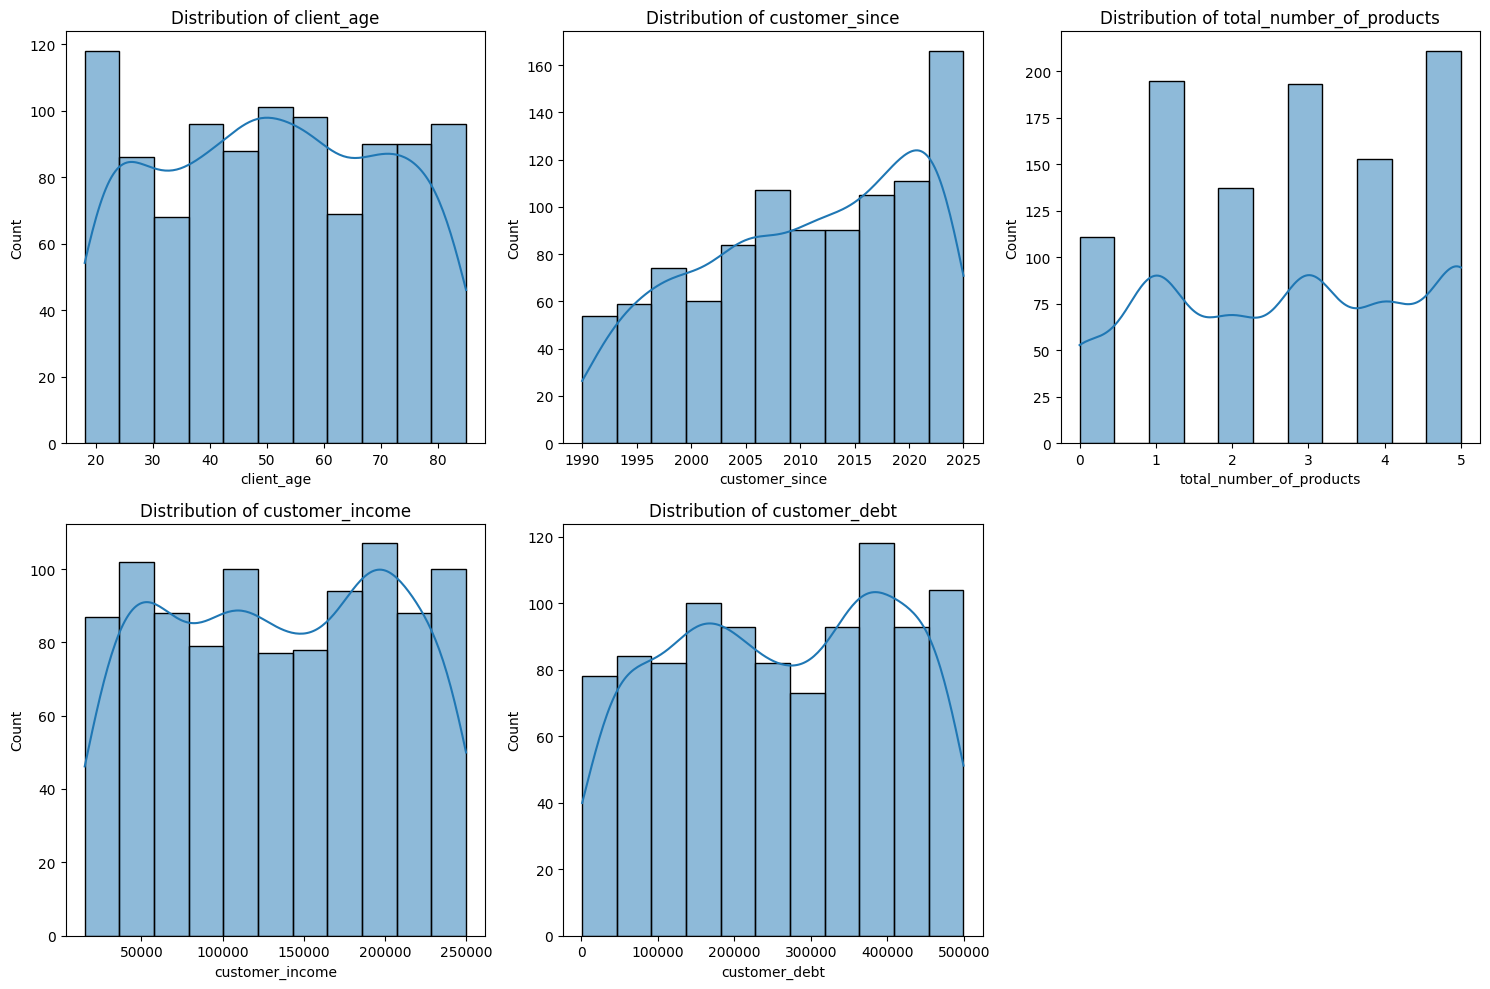


--- Countplots for Categorical Variables ---


/tmp/ipykernel_19550/1347577403.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_19550/1347577403.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_19550/1347577403.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_19550/1347577403.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

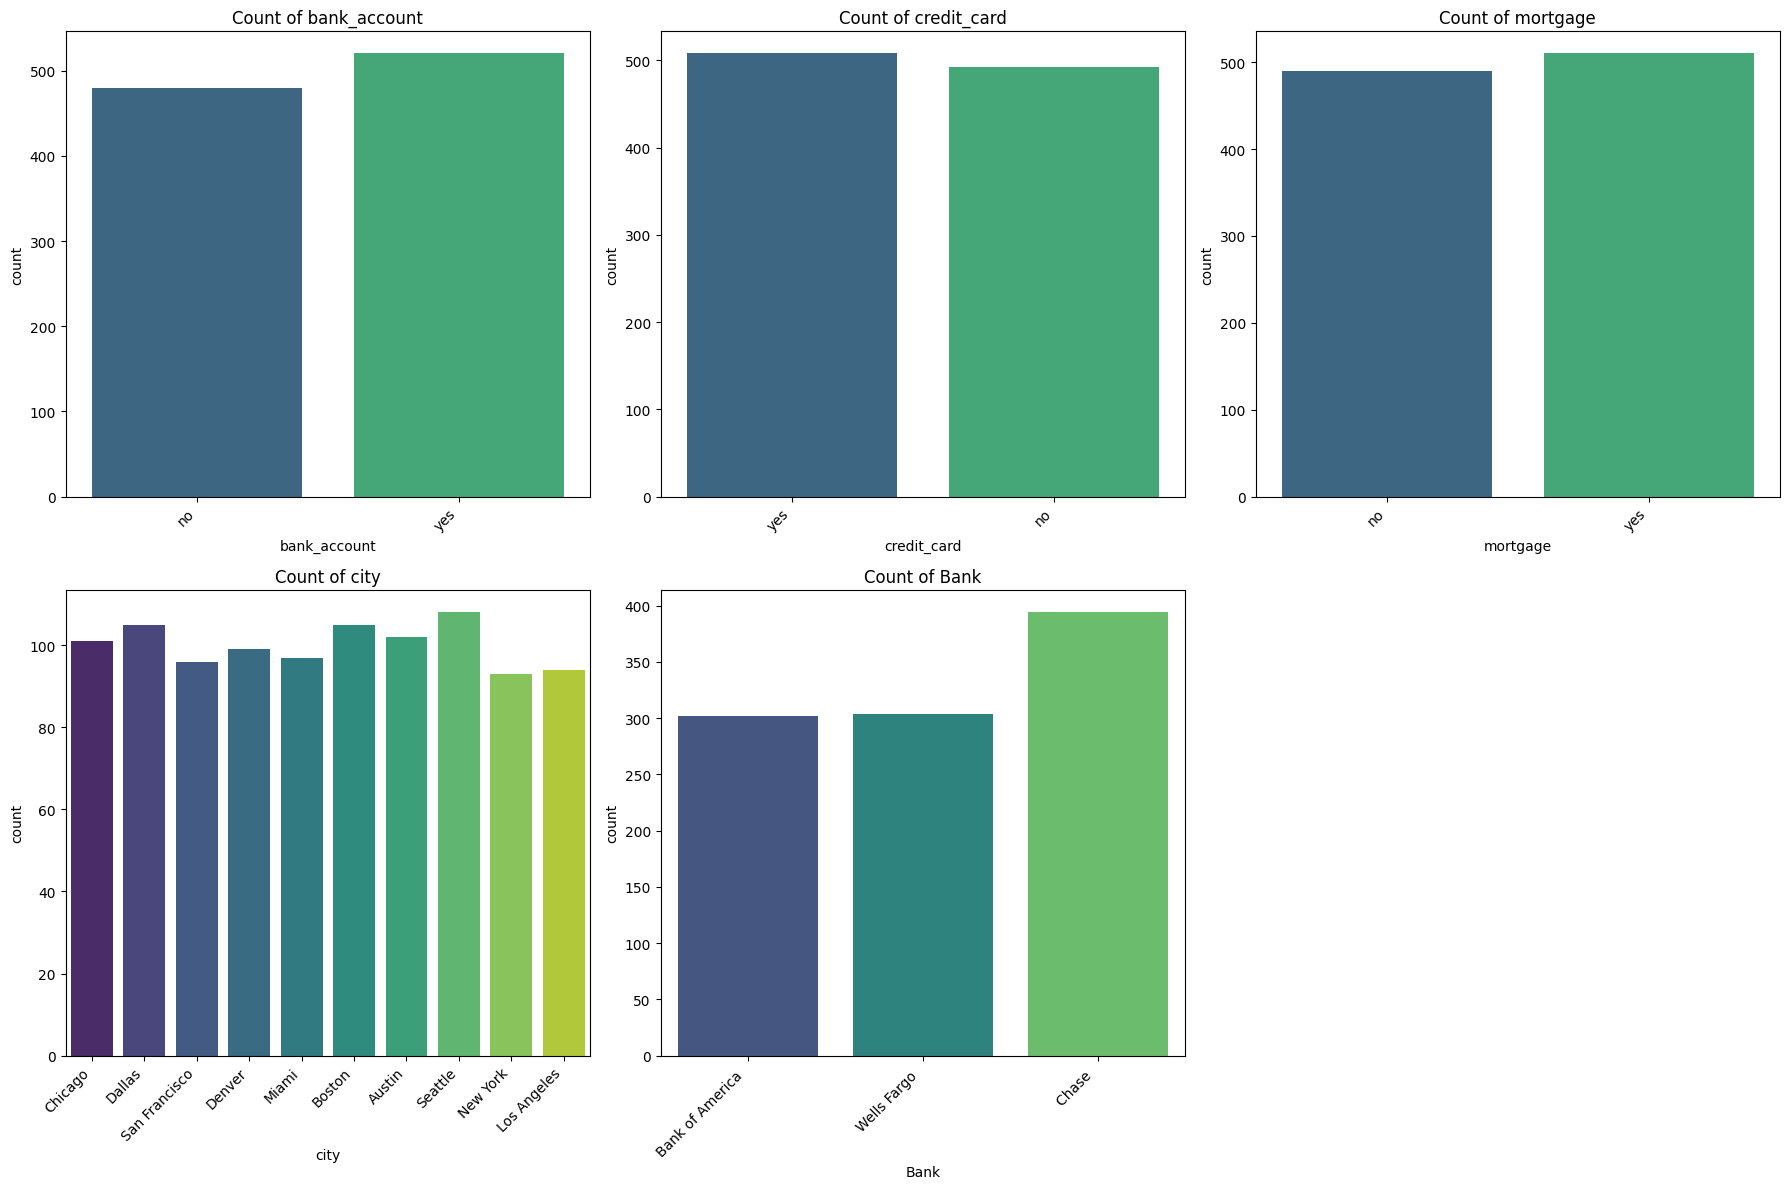

In [146]:
numerical_cols = ['client_age', 'customer_since', 'total_number_of_products', 'customer_income', 'customer_debt']
categorical_cols = ['bank_account', 'credit_card', 'mortgage', 'city', 'Bank']

# Histograms for numerical columns
print('--- Histograms for Numerical Variables ---')
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

# Countplots for specified categorical columns
print('\n--- Countplots for Categorical Variables ---')
plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

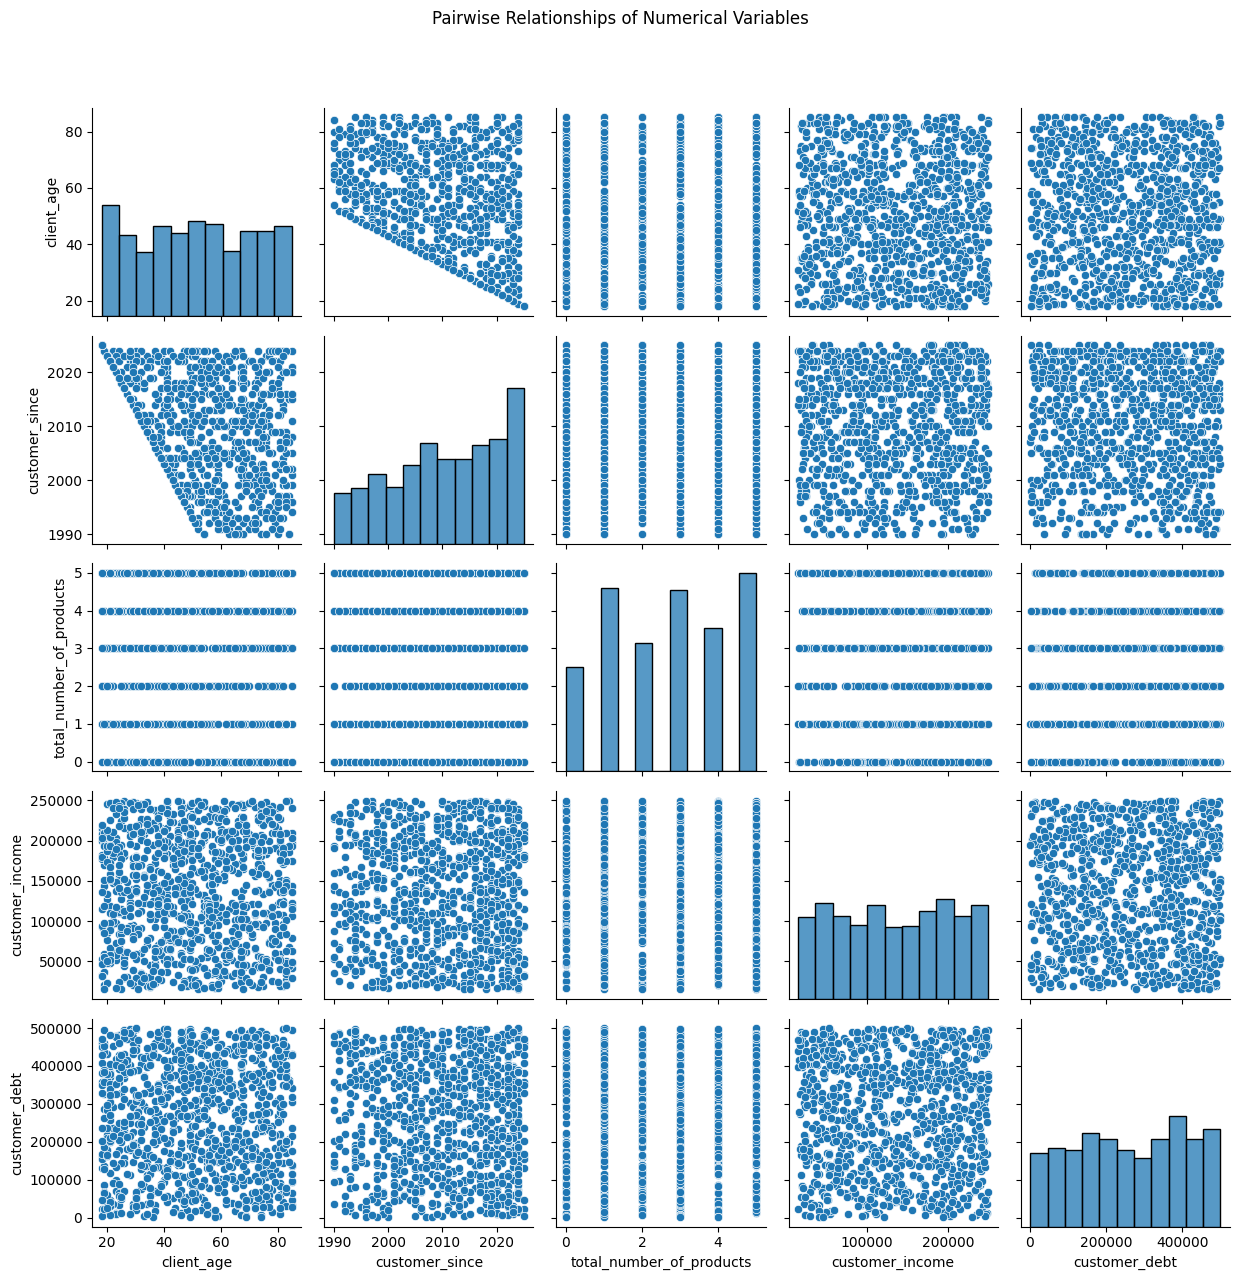

In [147]:
numerical_cols = ['client_age', 'customer_since', 'total_number_of_products', 'customer_income', 'customer_debt']

# Create a pairplot to visualize pairwise relationships between numerical variables
plt.figure(figsize=(12, 10))
sns.pairplot(df[numerical_cols])
plt.suptitle('Pairwise Relationships of Numerical Variables', y=1.02) # Adjust suptitle to not overlap
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

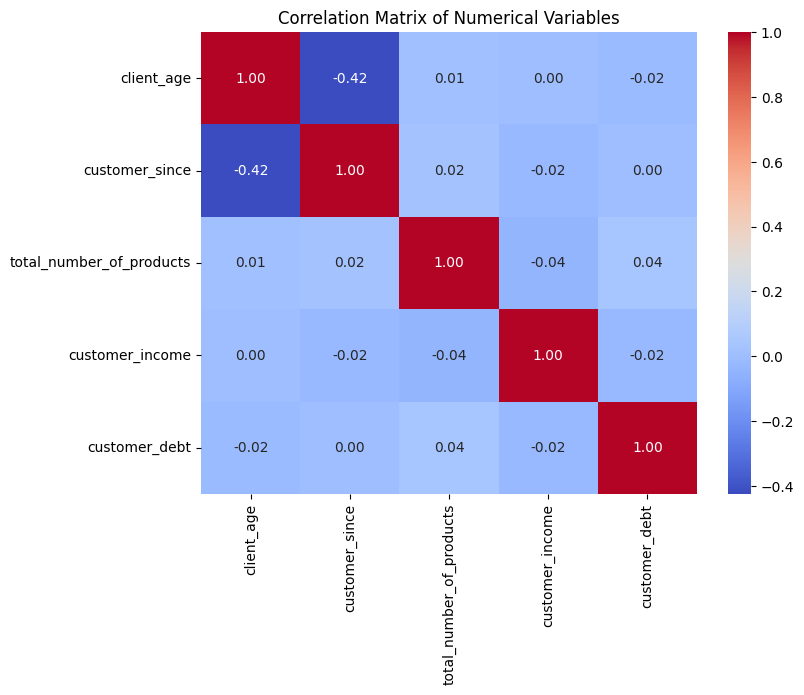

In [148]:
numerical_cols = ['client_age', 'customer_since', 'total_number_of_products', 'customer_income', 'customer_debt']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [149]:
df.columns

Index(['client_id', 'client_age', 'customer_since', 'bank_account',
       'credit_card', 'mortgage', 'total_number_of_products',
       'customer_income', 'customer_debt', 'city', 'Bank', 'Branch',
       'use_of_digital_channels', 'use_of_branches', 'bank_service_message'],
      dtype='object')

###2. Variables Seleccionadas y Modelos

In [150]:
# Define the numerical columns that will be used for modeling and scaling
selected_numerical_variables = ['customer_income','customer_debt']


# Create df_numerical_for_scaling by selecting only the numerical variables
df_numerical_for_scaling = df[selected_numerical_variables].copy()

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the selected numerical variables
scaled_numerical_features = scaler.fit_transform(df_numerical_for_scaling)

# Convert scaled_numerical_features back to a DataFrame for easier concatenation
scaled_numerical_df = pd.DataFrame(scaled_numerical_features, columns=selected_numerical_variables, index=df.index)

df_mod = scaled_numerical_df
print("First 5 rows of df_mod after selecting variables, scaling, and one-hot encoding:")
print(df_mod.head())

# Update scaled_features to be the combined data for consistency with later cells
scaled_features = df_mod.values

First 5 rows of df_mod after selecting variables, scaling, and one-hot encoding:
   customer_income  customer_debt
0         1.450851       1.080108
1        -1.705772       1.445175
2         0.711007      -0.786386
3        -1.472067      -1.251171
4        -1.380247       0.406305


In [151]:
kmeans = KMeans(
  init="random", # Este parámetro determina donde se ubican los centroides inicialmente
  n_clusters=4, # Corresponde al número de clusters que se van a crear
  n_init=10, # El número de veces que se iniciarán los centroides para seleccionar los mejores, según la inercia
  max_iter=300, # Número máximo de iteraciones para encontrar los clusters optimos
  random_state=42 # Este valor asegura que los resultados son reproducibles
  )

In [152]:
kmeans.fit(scaled_features)
kmeans_labels = kmeans.labels_
silhouette_avg = silhouette_score(scaled_features, kmeans_labels)
print("Kmeans Silhouette Score:", silhouette_avg)

Kmeans Silhouette Score: 0.42582074484810145


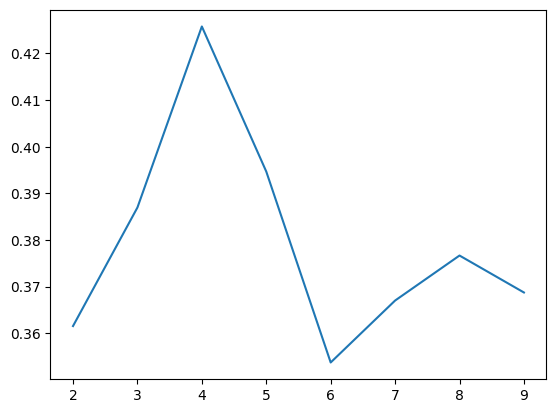

In [153]:
silueta =[]
n_cluster=range(2,10)
for i in n_cluster:
  kmeans = KMeans(i)
  kmeans.fit(scaled_features)
  score = silhouette_score(scaled_features,kmeans.labels_ )
  silueta.append(score)
plt.plot( list(n_cluster), silueta  )

In [154]:
dbs = DBSCAN(eps=1.0, min_samples=300)
dbs.fit(scaled_features)

DBSCAN(eps=1.0, min_samples=300)

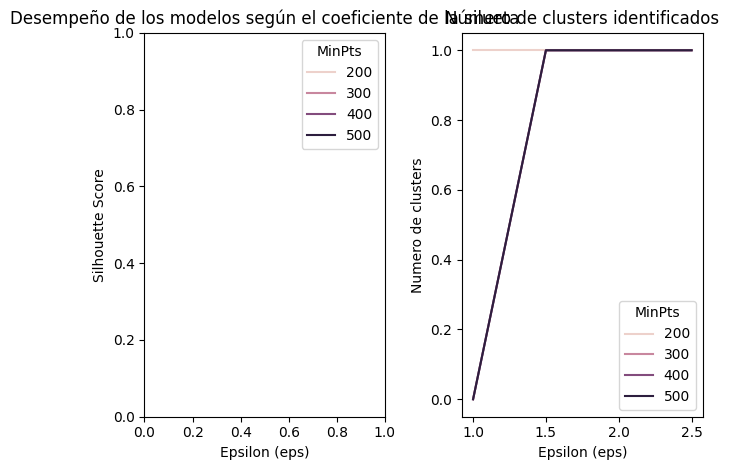

In [155]:
eps_values = [1.0,1.5,2.0,2.5]
minPts_values = [200,300,400,500]
results = []
for i, minPts in enumerate(minPts_values):
    for j, eps in enumerate(eps_values):

        dbscan_model = DBSCAN(eps=eps, min_samples=minPts)
        dbscan_labels = dbscan_model.fit_predict(scaled_features)
        unique_labels = set(dbscan_model.labels_)
        unique_labels.discard(-1)
        num_clusters = len(unique_labels)

        silhouette_avg = np.nan # Default to NaN if score cannot be computed
        if num_clusters >= 2: # Silhouette score requires at least 2 clusters
            silhouette_avg = silhouette_score(scaled_features, dbscan_labels)

        results.append({
            'Epsilon (eps)': eps,
            'MinPts': minPts,
            'Silhouette Score': silhouette_avg,
            'Numero de clusters': num_clusters
        })
results_df= pd.DataFrame(results)
fig, axes = plt.subplots(1, 2)
sns.lineplot(x=results_df['Epsilon (eps)'], y=results_df['Silhouette Score'], hue=results_df['MinPts'], ax=axes[0])
axes[0].set_title('Desempeño de los modelos según el coeficiente de la silueta') # Set title for the first subplot
sns.lineplot(x=results_df['Epsilon (eps)'], y=results_df['Numero de clusters'], hue=results_df['MinPts'],ax=axes[1] )
axes[1].set_title('Número de clusters identificados') # Set title for the second subplot
plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

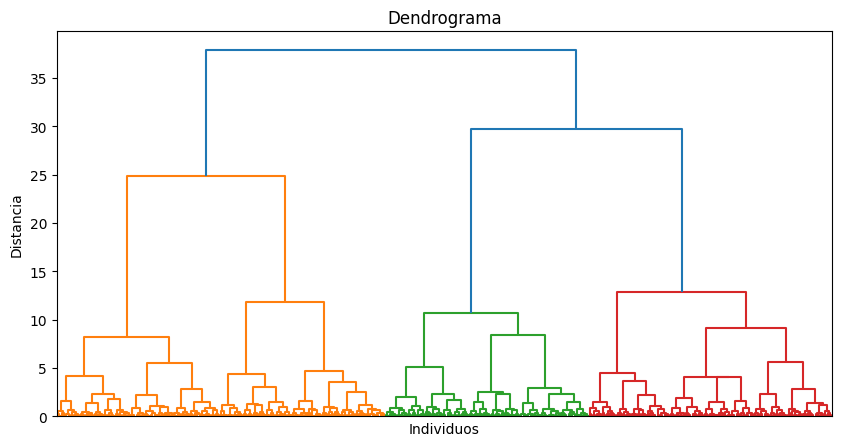

In [156]:
# visualización clustering jerarquico
dist_matrix = linkage(scaled_features, method='ward')
# Visualizar el dendrograma
plt.figure(figsize=(10, 5))
dendrogram(dist_matrix,no_labels=True)
plt.title('Dendrograma')
plt.xlabel('Individuos')
plt.ylabel('Distancia')
plt.show()

In [157]:
jerarquico = AgglomerativeClustering(4)
jerarquico.fit(scaled_features )
jerarquico.labels_
jerarquico_labels = jerarquico.labels_
silhouette_avg = silhouette_score(scaled_features, jerarquico_labels)
print("Jerarquico Silhouette Score:", silhouette_avg)

Jerarquico Silhouette Score: 0.3870533534261249


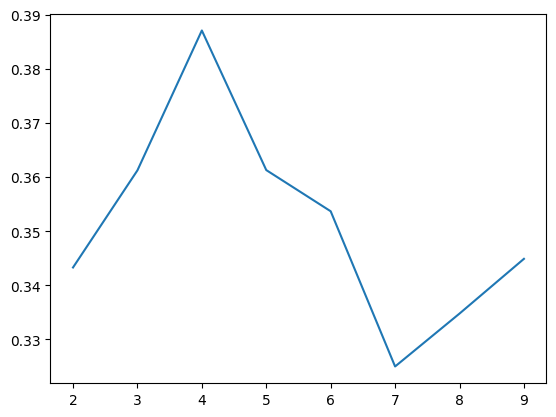

In [158]:
silueta =[]
n_cluster=range(2,10)
for i in n_cluster:
  jerarquico = AgglomerativeClustering(i)
  jerarquico.fit(scaled_features)
  score = silhouette_score(scaled_features,jerarquico.labels_ )
  silueta.append(score)
plt.plot( list(n_cluster), silueta  )

In [159]:
df['KMeans_Cluster'] = kmeans_labels
df.head()

,client_id,client_age,customer_since,bank_account,credit_card,mortgage,total_number_of_products,customer_income,customer_debt,city,Bank,Branch,use_of_digital_channels,use_of_branches,bank_service_message,KMeans_Cluster
0,SHZV-1493-NEVC-8912,78,2016,no,yes,no,3,234567.54,417219.52,Chicago,Bank of America,Magnificent Mile,medium,low,I've had an excellent experience with the bank...,0
1,SULL-1078-YORL-8055,58,2018,no,no,no,0,16333.04,469993.65,Dallas,Wells Fargo,Main Street Dallas,low,medium,I've had an excellent experience with the bank...,1
2,WLYJ-9126-OZSF-4196,76,2007,yes,yes,yes,5,183418.08,147398.45,San Francisco,Bank of America,Embarcadero,medium,low,My recent interactions with the bank have been...,3
3,VZMD-7697-CKUK-6198,59,2002,yes,no,no,5,32490.32,80208.97,San Francisco,Bank of America,Embarcadero,high,medium,I've had an excellent experience with the bank...,2
4,WTBA-2990-KOZM-6501,67,2021,yes,no,no,2,38838.38,319814.33,Denver,Chase,Denver 16th Street,medium,high,My experience with the bank has been generally...,1


### 3. Análisis de los Clústeres K-Means

/tmp/ipykernel_19550/2531024361.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='KMeans_Cluster', palette='viridis')


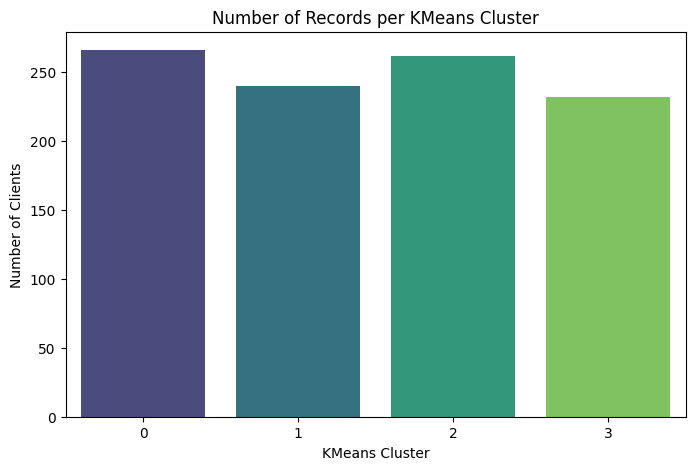


--- Visualizing Numerical Features Analysis by KMeans Cluster ---


/tmp/ipykernel_19550/2531024361.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='KMeans_Cluster', y=col, ax=axes[i], palette='viridis', ci=None) # ci=None to remove confidence intervals
/tmp/ipykernel_19550/2531024361.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='KMeans_Cluster', y=col, ax=axes[i], palette='viridis', ci=None) # ci=None to remove confidence intervals
/tmp/ipykernel_19550/2531024361.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='KMeans_Cluster', y=col, ax=axes[i], palette='viridis', ci=None) # ci=None to remove confidence intervals
/tmp/ipykernel_19550/2531024361.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

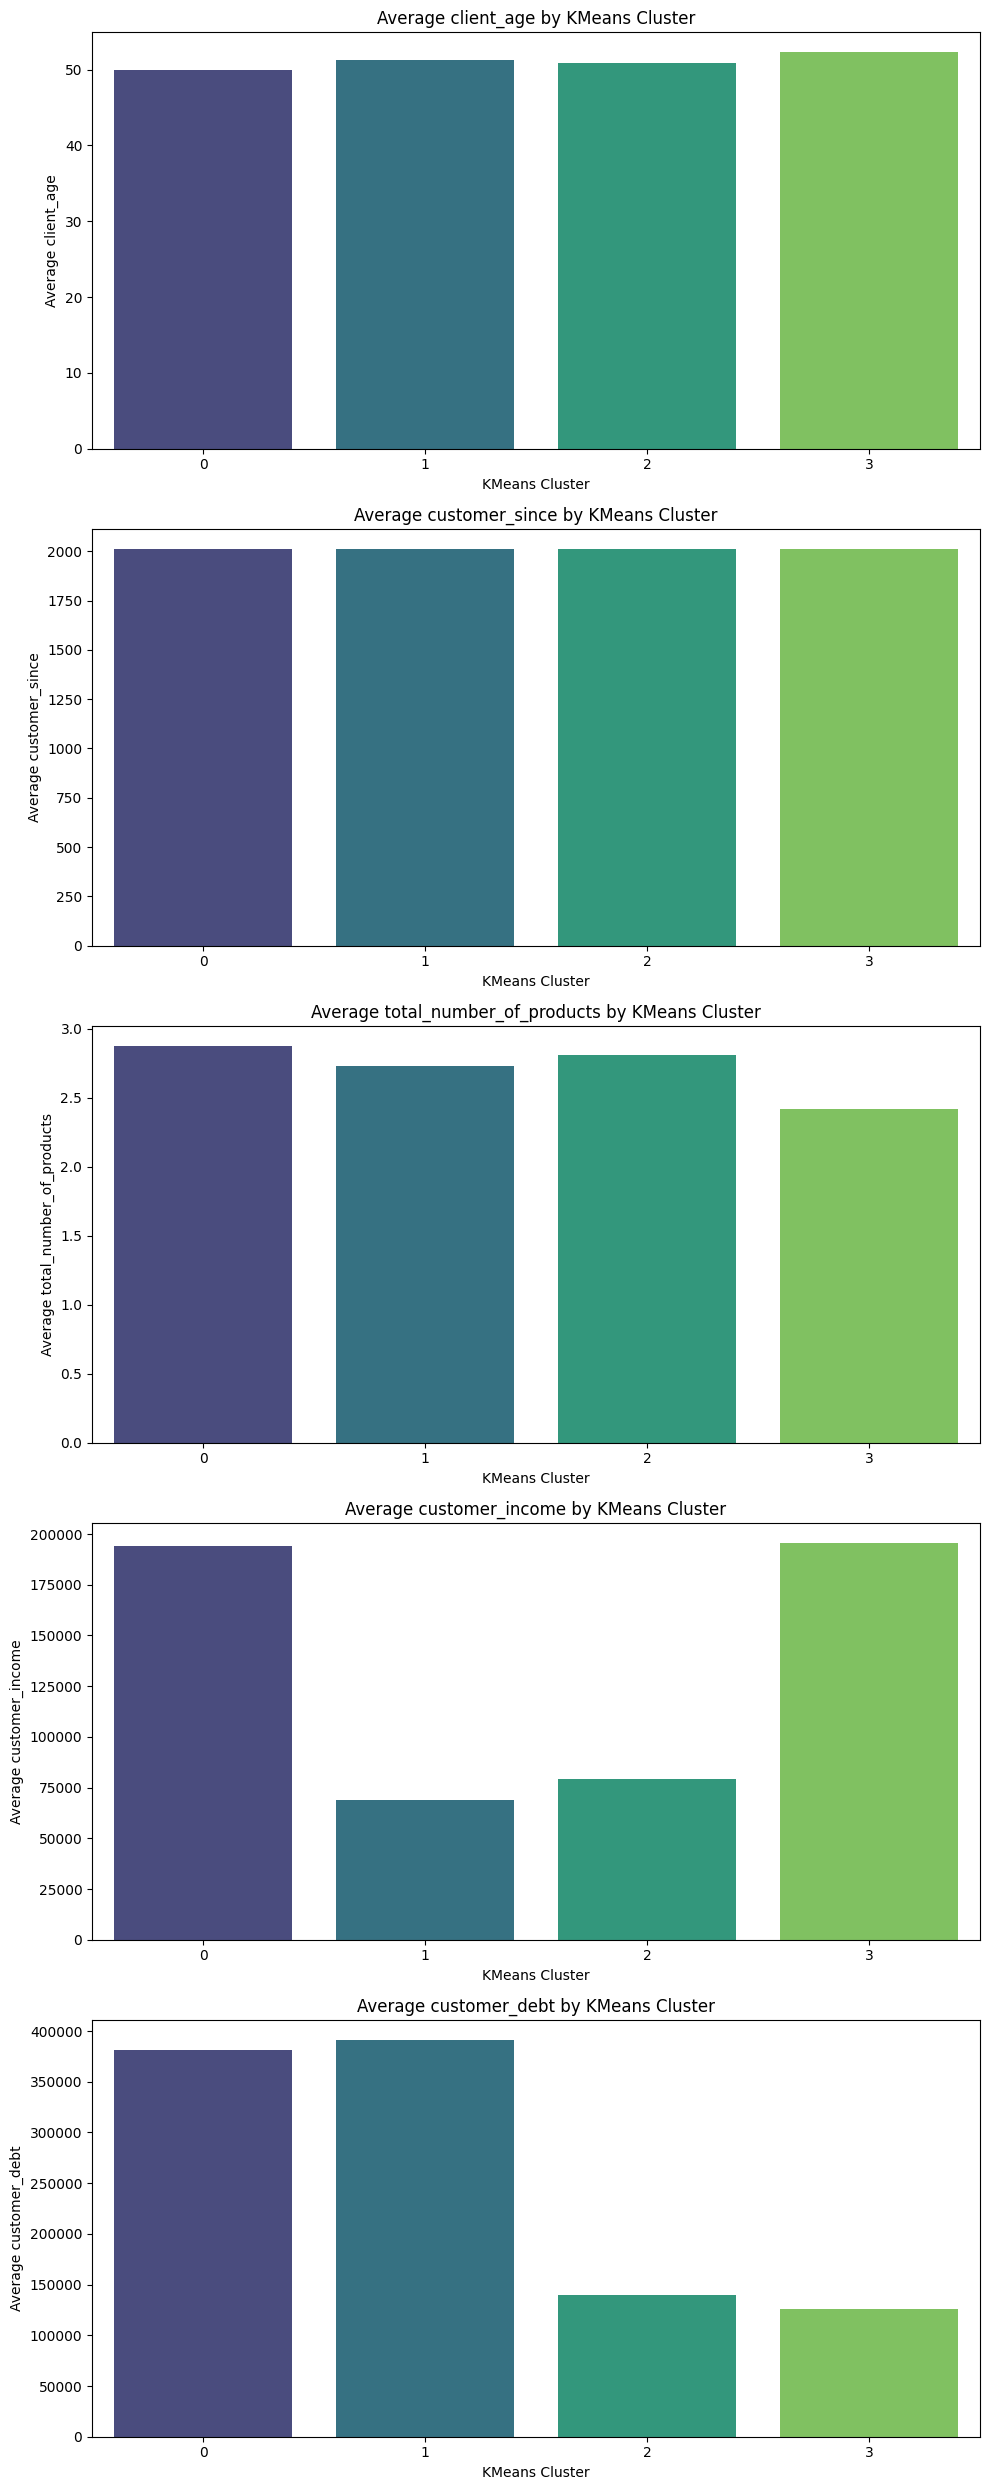


--- Visualizing Categorical Features Analysis by KMeans Cluster ---


<Figure size 1000x600 with 0 Axes>

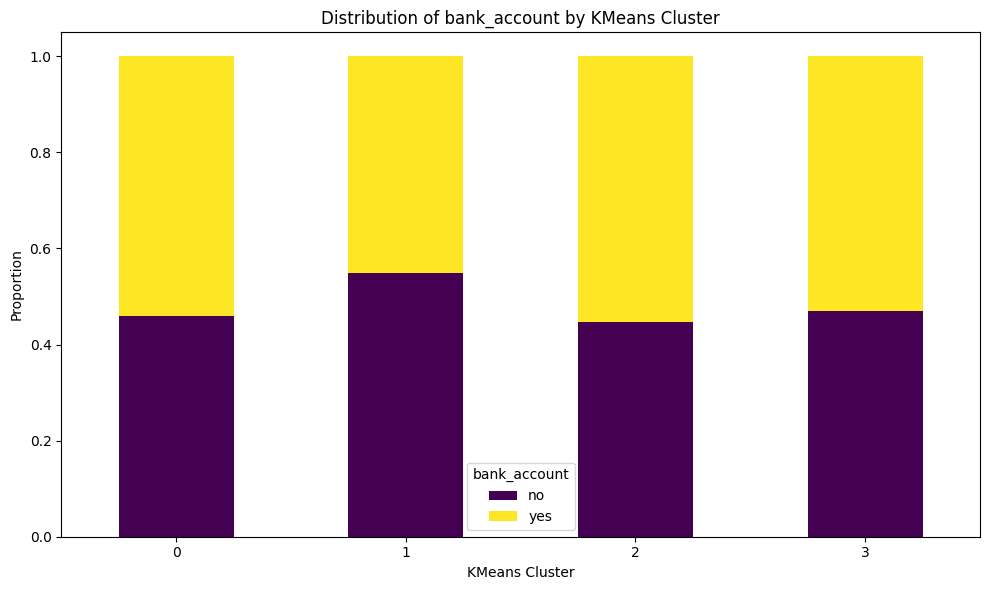

<Figure size 1000x600 with 0 Axes>

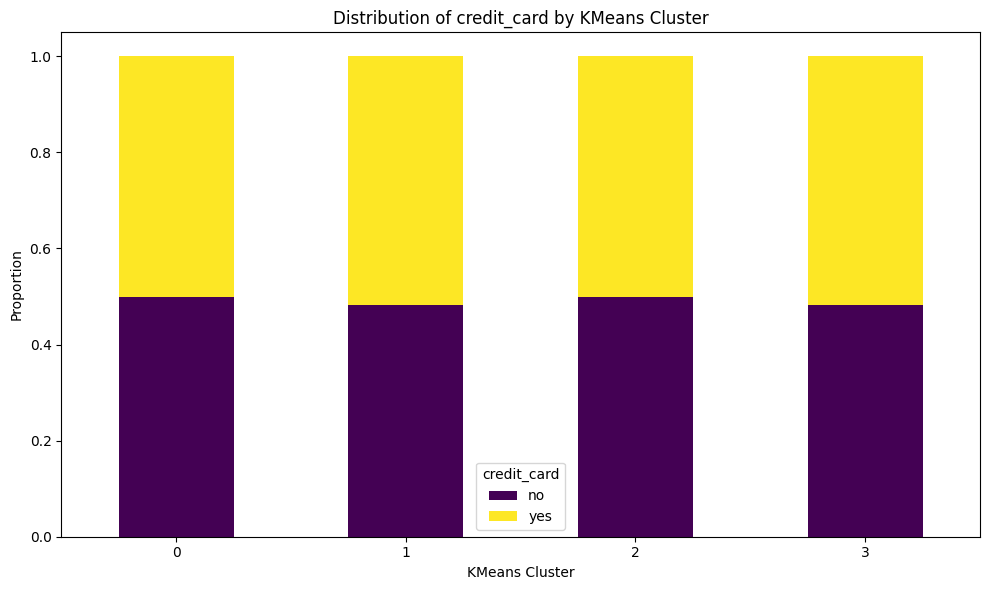

<Figure size 1000x600 with 0 Axes>

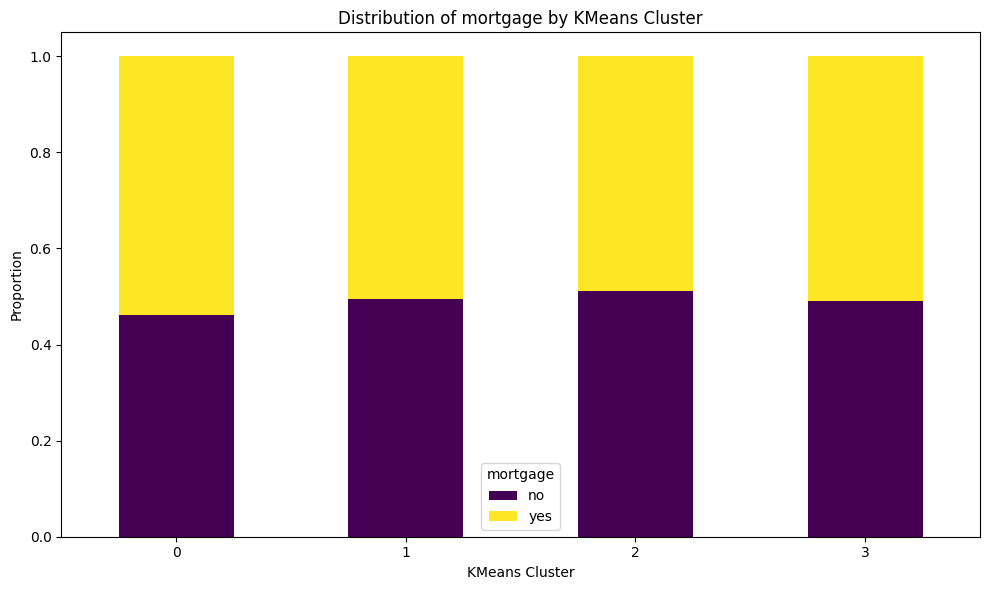

<Figure size 1000x600 with 0 Axes>

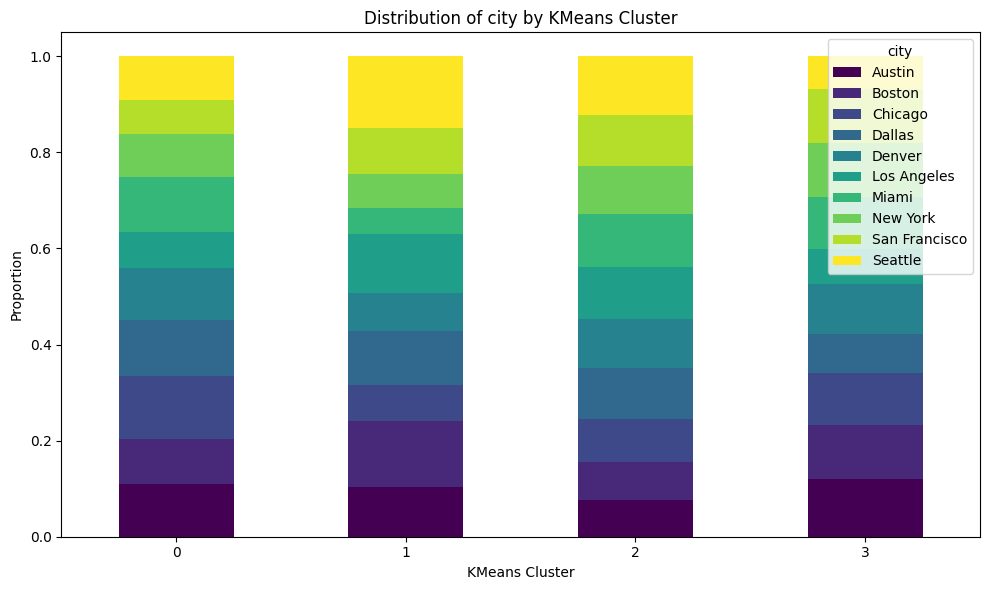

<Figure size 1000x600 with 0 Axes>

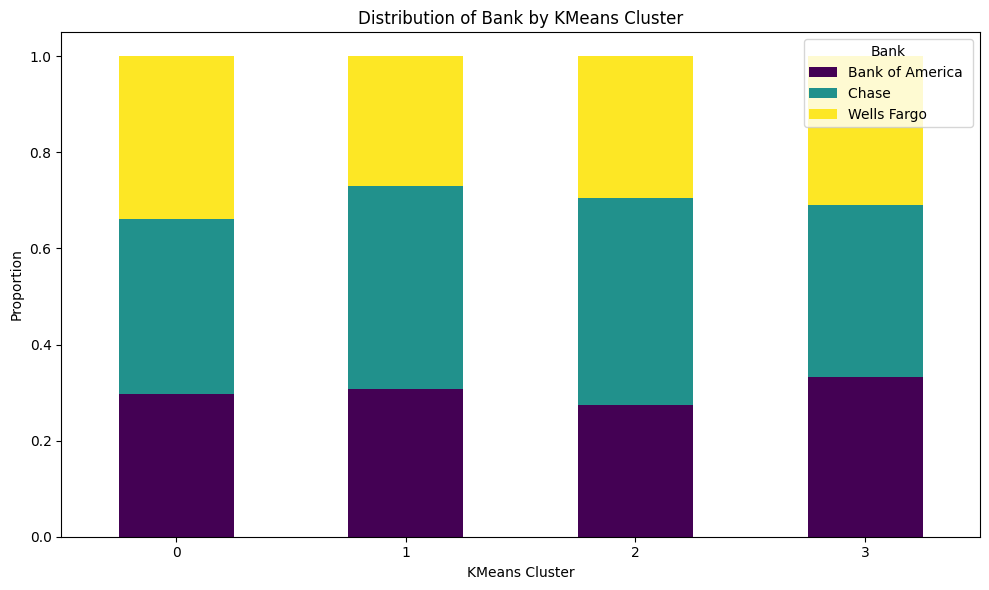

<Figure size 1000x600 with 0 Axes>

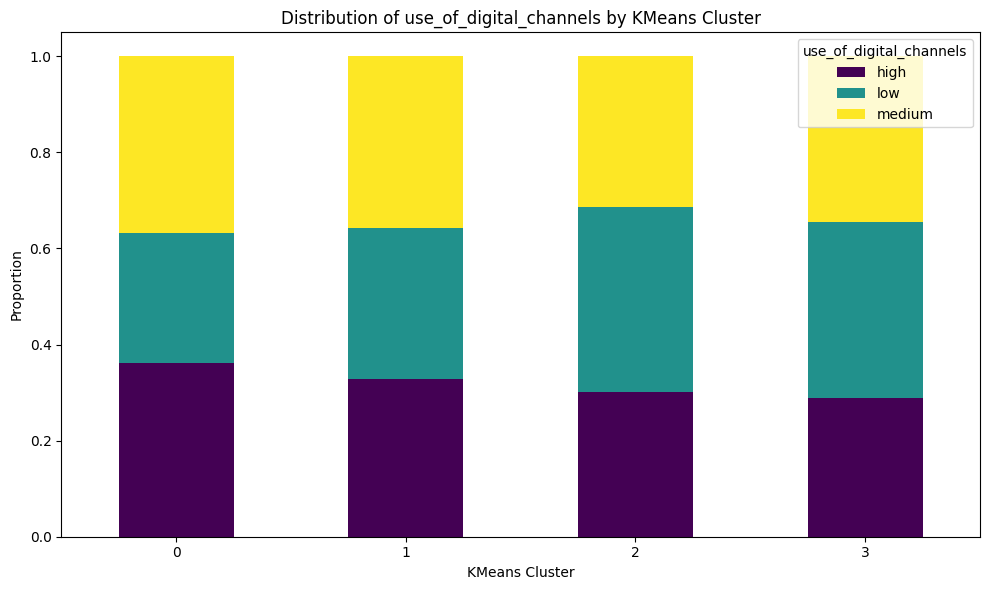

<Figure size 1000x600 with 0 Axes>

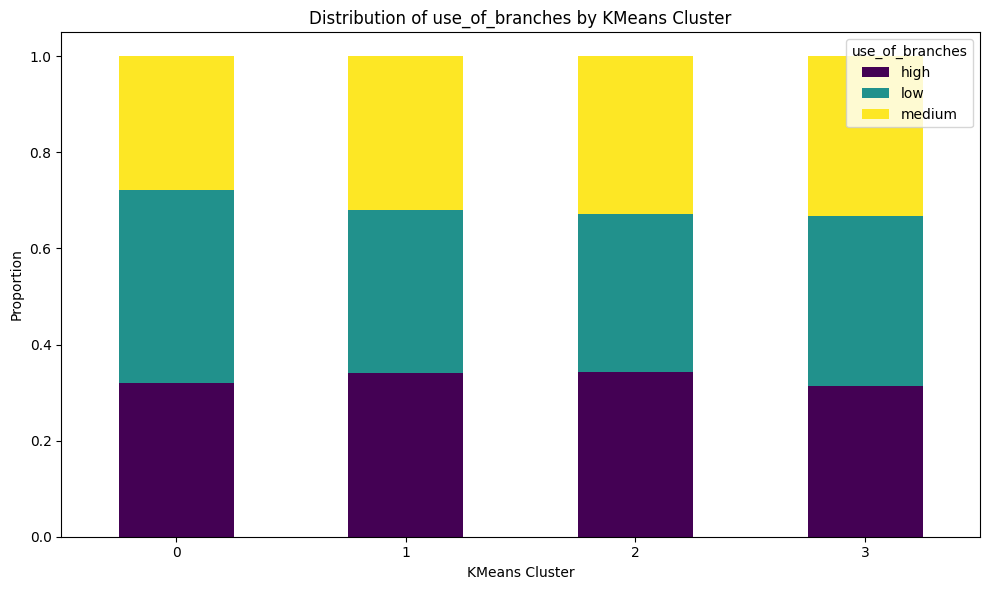

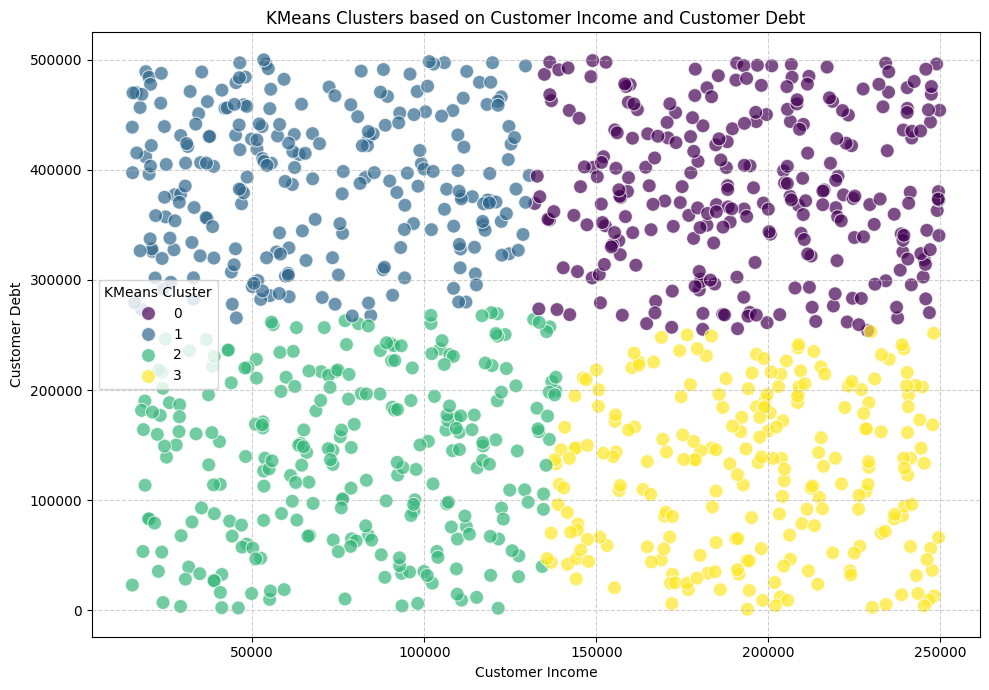

In [160]:
# First, define all relevant columns for plotting.
# The user specifically mentioned 'use_of_digital_channels' and 'use_of_branches'.
all_categorical_cols = categorical_cols + ['use_of_digital_channels', 'use_of_branches']

# 1. Number of records per cluster
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='KMeans_Cluster', palette='viridis')
plt.title('Number of Records per KMeans Cluster')
plt.xlabel('KMeans Cluster')
plt.ylabel('Number of Clients')
plt.show()

# 2. Average numerical features by cluster
print("\n--- Visualizing Numerical Features Analysis by KMeans Cluster ---")
# Create subplots dynamically based on the number of numerical columns
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(10, 5 * len(numerical_cols)))
# Ensure axes is an array even if there's only one numerical column
if len(numerical_cols) == 1:
    axes = [axes]

for i, col in enumerate(numerical_cols):
    sns.barplot(data=df, x='KMeans_Cluster', y=col, ax=axes[i], palette='viridis', ci=None) # ci=None to remove confidence intervals
    axes[i].set_title(f'Average {col} by KMeans Cluster')
    axes[i].set_xlabel('KMeans Cluster')
    axes[i].set_ylabel(f'Average {col}')
plt.tight_layout()
plt.show()

# 3. Distribution of categorical features by cluster
print("\n--- Visualizing Categorical Features Analysis by KMeans Cluster ---")
for col in all_categorical_cols:
    plt.figure(figsize=(10, 6))
    # Using crosstab to get proportions within each cluster for plotting
    ct = pd.crosstab(df['KMeans_Cluster'], df[col], normalize='index')
    ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
    plt.title(f'Distribution of {col} by KMeans Cluster')
    plt.xlabel('KMeans Cluster')
    plt.ylabel('Proportion')
    plt.xticks(rotation=0)
    plt.legend(title=col)
    plt.tight_layout()
    plt.show()

# Additionally, a scatter plot for customer_income and customer_debt colored by cluster
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='customer_income', y='customer_debt', hue='KMeans_Cluster', palette='viridis', s=100, alpha=0.7)
plt.title('KMeans Clusters based on Customer Income and Customer Debt')
plt.xlabel('Customer Income')
plt.ylabel('Customer Debt')
plt.legend(title='KMeans Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


###4. Analisis de sentimientos de cada cluster

In [161]:
import nltk # paquete 1 de lenguaje natural para procesamiento de texto
import re # paquete 2 de lenguaje natural lexicon o polaridad de las palabras
from nltk.corpus import stopwords # conjunto de stopwords
from nltk.tokenize import TweetTokenizer # tokenizador de tweet
from nltk.stem import PorterStemmer # hacer steming palabras
from nltk.stem import LancasterStemmer # hacer steming palabras
from nltk.stem import WordNetLemmatizer # extraer el lema de una palabra
import matplotlib.pyplot as plt
from wordcloud import WordCloud  # graficos de palabras
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('words')
nltk.download('wordnet')
nltk.download('omw-1.4')

#Analisis de sentimientos
from textblob import TextBlob
import csv
import re
import time
import string

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [162]:
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_emojis(text):
    emoji_pattern = re.compile(r'['  # Start of emoji pattern
                           r'\U0001F600-\U0001F64F'  # emoticons
                           r'\U0001F300-\U0001F5FF'  # symbols & pictographs
                           r'\U0001F680-\U0001F6FF'  # transport & map symbols
                           r'\U0001F1E0-\U0001F1FF'  # flags (iOS)
                           r'\U00002702-\U000027B0' # Dingbats
                           r'\U000024C2-\U0001F251' # Enclosed characters
                           r']+', flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def remove_special_characters(text):
    # Keep alphanumeric and spaces, remove others
    return re.sub(r'[^a-zA-Z0-9\s]', '', text)

# Apply the cleaning functions to the 'bank_service_message' column
df['bank_service_message'] = df['bank_service_message'].apply(remove_urls)
df['bank_service_message'] = df['bank_service_message'].apply(remove_emojis)
df['bank_service_message'] = df['bank_service_message'].apply(remove_special_characters)

df.head()

,client_id,client_age,customer_since,bank_account,credit_card,mortgage,total_number_of_products,customer_income,customer_debt,city,Bank,Branch,use_of_digital_channels,use_of_branches,bank_service_message,KMeans_Cluster
0,SHZV-1493-NEVC-8912,78,2016,no,yes,no,3,234567.54,417219.52,Chicago,Bank of America,Magnificent Mile,medium,low,Ive had an excellent experience with the banks...,0
1,SULL-1078-YORL-8055,58,2018,no,no,no,0,16333.04,469993.65,Dallas,Wells Fargo,Main Street Dallas,low,medium,Ive had an excellent experience with the banks...,1
2,WLYJ-9126-OZSF-4196,76,2007,yes,yes,yes,5,183418.08,147398.45,San Francisco,Bank of America,Embarcadero,medium,low,My recent interactions with the bank have been...,3
3,VZMD-7697-CKUK-6198,59,2002,yes,no,no,5,32490.32,80208.97,San Francisco,Bank of America,Embarcadero,high,medium,Ive had an excellent experience with the banks...,2
4,WTBA-2990-KOZM-6501,67,2021,yes,no,no,2,38838.38,319814.33,Denver,Chase,Denver 16th Street,medium,high,My experience with the bank has been generally...,1


In [163]:
text = ' '.join(df['bank_service_message']) # unir todos los textos, separados por espacio
text = text.lower()
tokens = text.split( ) # separa por espacios, \n, multiples espacios.
print( "Tokens: ", tokens[0:15] )
print("Cantidad tokens:",len(tokens ))
print("Cantidad Bag of words: ",len(set(tokens) ))

Tokens:  ['ive', 'had', 'an', 'excellent', 'experience', 'with', 'the', 'banks', 'helpful', 'financial', 'advice', 'their', 'team', 'is', 'consistently']
Cantidad tokens: 47690
Cantidad Bag of words:  155


In [164]:
stop_words_nltk_en =list(set(stopwords.words('english')))
print(stop_words_nltk_en)
len(stop_words_nltk_en)
tokens_sin_stop=[w for w in tokens if w not in stop_words_nltk_en]
print( "Tokens: ", tokens_sin_stop[0:15] )
print("Cantidad tokens:",len(tokens_sin_stop ))
print("Cantidad Bag of words: ",len(set(tokens_sin_stop) ))

["it'll", 'so', 'an', 'mightn', 'other', 'a', 'can', 'over', 'weren', 'once', "you've", 'its', 'this', 'had', 'couldn', 'into', 'which', 'up', 'doing', 'our', 'own', "wasn't", 'for', 'wasn', 'he', 'why', 'where', 'now', 'i', 'didn', 's', 'out', 'off', "i've", 'because', 'against', 'whom', 'me', 'you', 'm', "it's", 'it', 'll', 'who', 'hadn', 'if', 'below', 'but', "he'd", 't', 'ain', 'to', "they're", "you'd", 'any', "i'd", 'few', 'am', "they've", 'is', "we've", 'all', 'while', 'too', 'through', 'having', "needn't", "you'll", "she'll", "shouldn't", "i'm", "mightn't", "didn't", 'such', "it'd", "aren't", 'some', 'before', 'very', 'there', 'd', 'was', 'haven', 'has', 'themselves', 'during', 'ours', "don't", 'does', 'don', 'being', "he's", 'most', 'the', 'them', 'those', 'be', 'from', 'him', 'or', 'your', 'under', "doesn't", "he'll", 'further', 'only', 'hers', 'theirs', "won't", 'his', 'same', 'not', "we'd", 'that', "they'll", 'in', "we're", 'have', 'isn', 'her', "should've", 'my', 'hasn', "w

In [165]:
porter = PorterStemmer() # Algotimo Stemming
tokens_stem = stem_strings1=[porter.stem(w) for w in tokens_sin_stop]
print("Stemming" )
# print( "Tokens: ", tokens_stem )
print("Cantidad tokens:",len(tokens_stem ))
# print( "Bag of words: ", set(tokens_stem)  )
print("Cantidad Bag of words: ",len(set(tokens_stem) ))
wordnet_lemmatizer = WordNetLemmatizer() # Algoritmo lemmatizar
tokens_lemma = [wordnet_lemmatizer.lemmatize(w) for w in tokens_sin_stop ]
print("Lematización")
# print( "Tokens: ", tokens_lemma )
print("Cantidad tokens:",len(tokens_lemma ))
# print( "Bag of words: ", set(tokens_lemma)  )
print("Cantidad Bag of words: ",len(set(tokens_lemma) ))

Stemming
Cantidad tokens: 30059
Cantidad Bag of words:  120
Lematización
Cantidad tokens: 30059
Cantidad Bag of words:  123


In [166]:
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words_nltk_en = set(stopwords.words('english'))
porter = PorterStemmer()
wordnet_lemmatizer = WordNetLemmatizer()

# Function to apply lemmatization after stopword removal and lowercasing
def process_text_for_sentiment(text):
    words = text.lower().split() # Tokenize by space and lowercase
    filtered_words = [word for word in words if word not in stop_words_nltk_en]
    lemmatized_words = [wordnet_lemmatizer.lemmatize(word) for word in filtered_words]
    return ' '.join(lemmatized_words)

# Create the new DataFrame 'df_ex' for sentiment analysis, using the correct message column
df_ex = pd.DataFrame()
df_ex['processed_text'] = df['bank_service_message'].apply(process_text_for_sentiment)

# Apply sentiment analysis using TextBlob
df_ex['sentiment_polarity'] = df_ex['processed_text'].apply(lambda text: TextBlob(text).sentiment.polarity)
df_ex['sentiment_subjectivity'] = df_ex['processed_text'].apply(lambda text: TextBlob(text).sentiment.subjectivity)

# Classify sentiment based on polarity
def get_sentiment_category(polarity):
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df_ex['sentiment_category'] = df_ex['sentiment_polarity'].apply(get_sentiment_category)

# Assign sentiment back to the original DataFrame using direct assignment, as indices are aligned
df['sentiment_polarity'] = df_ex['sentiment_polarity']
df['sentiment_subjectivity'] = df_ex['sentiment_subjectivity']
df['sentiment_category'] = df_ex['sentiment_category']

print("DataFrame 'df_ex' prepared for sentiment analysis:")
print(df_ex.head())
print("\nOriginal DataFrame 'df' with sentiment scores:")
print(df[['bank_service_message', 'sentiment_polarity', 'sentiment_subjectivity', 'sentiment_category']].head())

DataFrame 'df_ex' prepared for sentiment analysis:
                                      processed_text  sentiment_polarity  \
0  ive excellent experience bank helpful financia...            0.322857   
1  ive excellent experience bank fraud protection...            0.376667   
2  recent interaction bank disappointing particul...           -0.077778   
3  ive excellent experience bank seamless online ...            0.337143   
4  experience bank generally fine especially rega...            0.192517   

   sentiment_subjectivity sentiment_category  
0                0.462857           Positive  
1                0.540000           Positive  
2                0.230556           Negative  
3                0.477143           Positive  
4                0.542347           Positive  

Original DataFrame 'df' with sentiment scores:
                                bank_service_message  sentiment_polarity  \
0  Ive had an excellent experience with the banks...            0.322857   
1  Ive had

### 5. Análisis del sentimiento de los clientes por Clúster

Sentiment Distribution per KMeans Cluster:
sentiment_category  Negative  Positive
KMeans_Cluster                        
0                         69       197
1                         46       194
2                         56       206
3                         41       191

Sentiment Proportion per KMeans Cluster:
sentiment_category  Negative  Positive
KMeans_Cluster                        
0                   0.259398  0.740602
1                   0.191667  0.808333
2                   0.213740  0.786260
3                   0.176724  0.823276


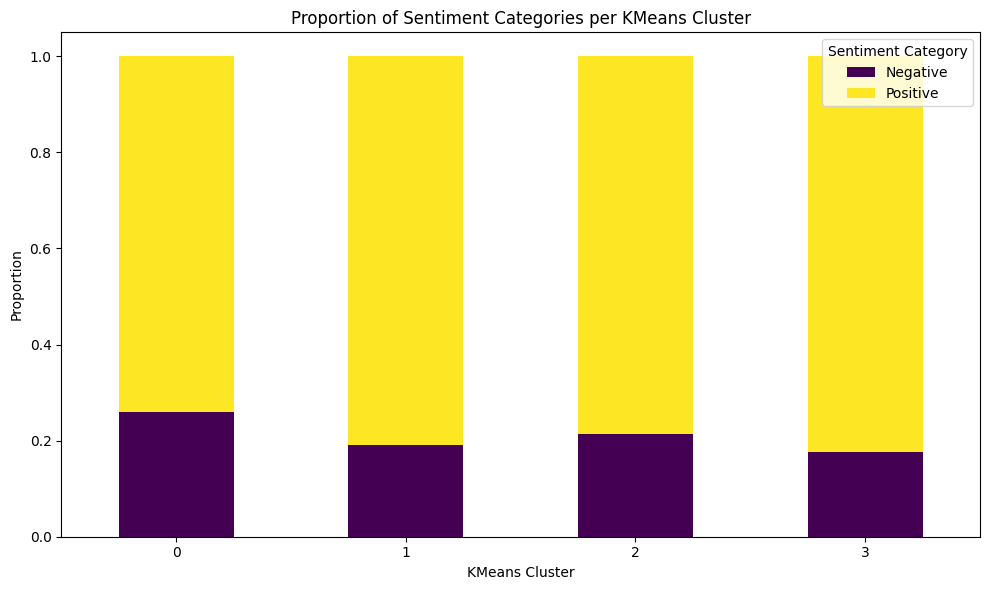


Average Sentiment Polarity per KMeans Cluster:
KMeans_Cluster
0    0.225635
1    0.249185
2    0.246152
3    0.257784
Name: sentiment_polarity, dtype: float64


/tmp/ipykernel_19550/134286089.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_polarity_per_cluster.index, y=average_polarity_per_cluster.values, palette='coolwarm')


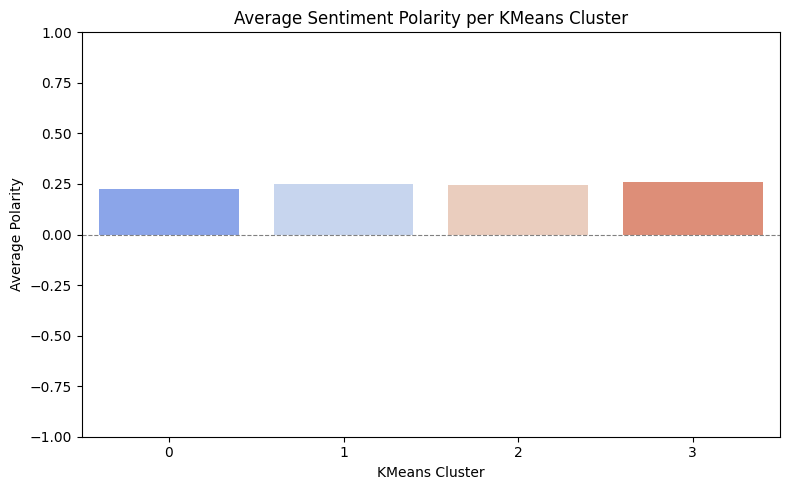

In [167]:
# Group by KMeans_Cluster and sentiment_category to count occurrences
sentiment_distribution = df.groupby(['KMeans_Cluster', 'sentiment_category']).size().unstack(fill_value=0)

# Calculate the proportion for each sentiment category within each cluster
sentiment_proportion = sentiment_distribution.apply(lambda x: x / x.sum(), axis=1)

print("Sentiment Distribution per KMeans Cluster:")
print(sentiment_distribution)
print("\nSentiment Proportion per KMeans Cluster:")
print(sentiment_proportion)

# Plotting the sentiment proportion per cluster
sentiment_proportion.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Proportion of Sentiment Categories per KMeans Cluster')
plt.xlabel('KMeans Cluster')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Sentiment Category')
plt.tight_layout()
plt.show()

# Calculate the average sentiment polarity for each cluster
average_polarity_per_cluster = df.groupby('KMeans_Cluster')['sentiment_polarity'].mean()

print("\nAverage Sentiment Polarity per KMeans Cluster:")
print(average_polarity_per_cluster)

# Plotting the average sentiment polarity per cluster
plt.figure(figsize=(8, 5))
sns.barplot(x=average_polarity_per_cluster.index, y=average_polarity_per_cluster.values, palette='coolwarm')
plt.title('Average Sentiment Polarity per KMeans Cluster')
plt.xlabel('KMeans Cluster')
plt.ylabel('Average Polarity')
plt.ylim(-1, 1) # Polarity ranges from -1 to 1
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a line at 0 for reference
plt.tight_layout()
plt.show()

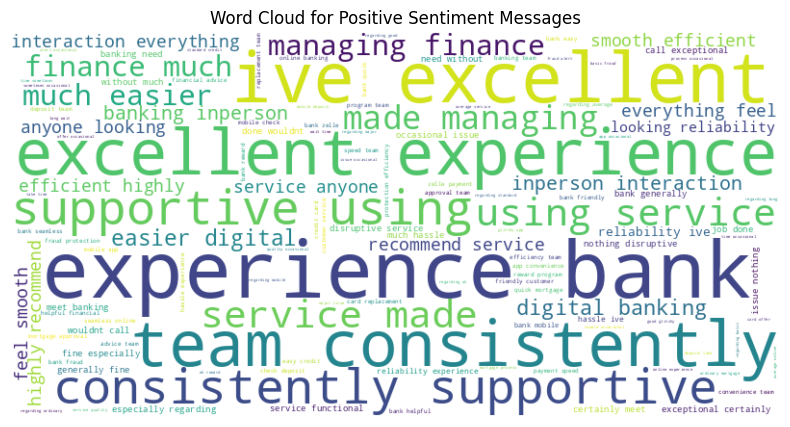

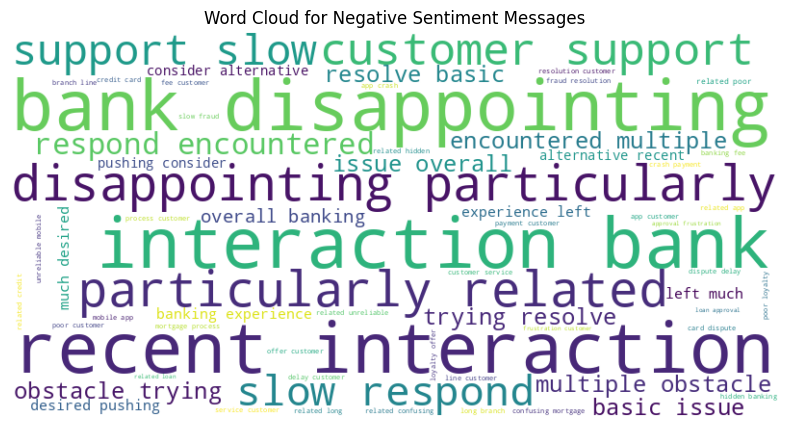

In [168]:
# Function to generate and display word cloud
def generate_word_cloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Get unique sentiment categories (Positive, Negative, Neutral)
sentiment_categories = ['Positive', 'Negative'] # Focus on Positive and Negative as requested

# Generate word cloud for each sentiment category
for sentiment_cat in sentiment_categories:
    # Filter messages for the current sentiment category
    sentiment_messages = df[df['sentiment_category'] == sentiment_cat]['bank_service_message']

    # Process messages using the existing function (lowercase, remove stopwords, lemmatize)
    processed_sentiment_messages = sentiment_messages.apply(process_text_for_sentiment)

    # Concatenate all processed messages into a single string
    combined_text = ' '.join(processed_sentiment_messages)

    # Generate and display the word cloud
    generate_word_cloud(combined_text, f'Word Cloud for {sentiment_cat} Sentiment Messages')


In [169]:
# Display messages with the highest positive polarity
print("\n--- 20 Mensajes con la polaridad más POSITIVA ---")
positive_messages = df.sort_values(by='sentiment_polarity', ascending=False).head(20)
for index, row in positive_messages.iterrows():
    print(f"Polaridad: {row['sentiment_polarity']:.2f} - Mensaje: {row['bank_service_message']}")

# Display messages with the highest negative polarity
print("\n--- 20 Mensajes con la polaridad más NEGATIVA ---")
negative_messages = df.sort_values(by='sentiment_polarity', ascending=True).head(20)
for index, row in negative_messages.iterrows():
    print(f"Polaridad: {row['sentiment_polarity']:.2f} - Mensaje: {row['bank_service_message']}")


--- 20 Mensajes con la polaridad más POSITIVA ---
Polaridad: 0.38 - Mensaje: Ive had an excellent experience with the banks easy credit card replacement Their team is consistently supportive and using their services has made managing my finances much easier From digital banking to inperson interactions everything feels smooth and efficient I highly recommend their service to anyone looking for reliability
Polaridad: 0.38 - Mensaje: Ive had an excellent experience with the banks easy credit card replacement Their team is consistently supportive and using their services has made managing my finances much easier From digital banking to inperson interactions everything feels smooth and efficient I highly recommend their service to anyone looking for reliability
Polaridad: 0.38 - Mensaje: Ive had an excellent experience with the banks easy credit card replacement Their team is consistently supportive and using their services has made managing my finances much easier From digital banking to

###Analisis de resultados
En el analisis exploratorio de la base de datos se encontro que en promedio los clientes tienen una edad de 51 años, son clientes de su banco desde 2010, tienen un ingreso de 132mil dolares al año y una deuda con su banco de 261mil dolares, en su mayoria tienen una cuenta, credito o tarjeta con el banco.

Para el diseño de los clusters se utilizaron las variables customer_income y customer_debt para la clasificacion de los cliente se descartaron las demas variables porque disminuian el puntaje de la silueta ya que se realizaron las transformaciones pertinetes y utilizaron diferentes combinaciones de variables y esta fue la mas efectiva y se dejo el modelo de K-means debido a que su puntuaje de la silueta era el mas elevado

Los clusters generados se encontraron los siguientes hallazgos, los cluster 0 y 3 se caracterizan por tener mayores ingresos respecto a los cluster 1 y 2 ademas de que los clusters 0 y 1 son los que mayores deudas poseen respecto al 2 y 3, los clusters 0 y 4 ademas utilizan mas los medios digitales de los bancos que los medio fisicos

En el analisis de sentimientos se encontro que los clientes en su mayoria estan contentos con el servicio prestado de banco siendo este un 70% 30% de mensajes positivos y negativos ademas se encontro que las principales causas de la satisfaccion esta relacionadas a la atencion de inconvenientes, reemplazo rapido de tarjetas de credito,la facilidad del uso de canales digitales y atencion rapida. En el caso de los negativos se encontro que hay un gran descontento con las ofertas o beneficios por longevidad con el banco, mala y lenta atencion al cliente

Para los bancos recomiendo seguir mejorando y manteniendo su atencion efectiva y rapida de los canales digitales y reforzar el uso de estos ademas de crear estrategias de markenting principalmente digital para el envio de campañas a usuarios de el cluster 0 y 1 ya que estos son los que mas deuda tiene y mayor de tarjeta de credito presentan con mensajes de promociones, beneficios o descuentos